In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import ast
import string
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

In [2]:
df = pd.read_csv('TKlemm0409v2.csv')

In [3]:
df.head()

,raw_rulings,head,sygn,type,rawDate,year,dateENG,grounds,vot_sep,tokens_grounds,grounds_len,votsep_ratio,votsep_len,grounds_lem
0,\n 1/1A/2004\...,\n 1/1A/2004\...,K 14/03,wyrok,7 stycznia 2004,2004,2004-01-07,i\n\n\n\n\n\n 1. grupa posłów na sejm we ...,Zdanie odrębne\n\n Sędziego Trybunału...,"['i', 'grupa', 'posłów', 'na', 'sejm', 'we', '...",15450,"['zdanie', 'odrębne', 'sędziego', 'trybunału',...",5311,"['i', '1', '.', 'grupa', 'poseł', 'na', 'sejm'..."
1,\n\n 8/2A/200...,\n\n 8/2A/200...,K 12/03,wyrok,18 lutego 2004,2004,2004-02-18,i\n\n\n\n\n a. przedmiot oceny trybunału ...,Zdanie odrębne\n\n sędzieg...,"['i', 'a', 'przedmiot', 'oceny', 'trybunału', ...",7676,"['zdanie', 'odrębne', 'sędziego', 'trybunału',...",3575,"['i', 'a', '.', 'przedmiot', 'ocena', 'trybuna..."
2,\n 10/2A/2004\...,\n 10/2A/2004\...,K 54/02,wyrok,24 lutego 2004,2004,2004-02-24,i\n\n\n\n 1. niezależny samorządny związe...,NAN,"['i', 'niezależny', 'samorządny', 'związek', '...",12480,['nan'],1,"['i', '1', '.', 'niezależny', 'samorządny', 'z..."
3,\n 15/2A/2004\...,\n 15/2A/2004\...,K 35/03,postanowienie,25 lutego 2004,2004,2004-02-25,i\n\n\n 1. pismem z 16 kwietnia 2003 r. r...,NAN,"['i', 'pismem', 'z', 'kwietnia', 'r', 'r', 'ko...",791,['nan'],1,"['i', '1', '.', 'pismo', 'z', '16', 'kwiecień'..."
4,\n\n 14/2A/200...,\n\n 14/2A/200...,K 23/03,postanowienie,25 lutego 2004,2004,2004-02-25,i\n\n\n pismem z 16 grudnia 2003 r. józef...,NAN,"['i', 'pismem', 'z', 'grudnia', 'r', 'józef', ...",567,['nan'],1,"['i', 'pismo', 'z', '16', 'grudzień', '2003', ..."


In [4]:
def load_stopwords():
    filepath = 'polish.stopwords.txt'
    with open(filepath, 'r', encoding='utf-8') as f:
        stopwords = set(line.strip().lower() for line in f if line.strip())
    return stopwords

def clean_tokens(tokens):
    stop_words = load_stopwords()
    replacements = {
        'ipna': 'IPN',
        'vot': 'vat'                        
    }
    cleaned = []
    for token in tokens:
        token_lower = token.lower()
        # if token_lower in stop_words:
        #     continue
        if token_lower in string.punctuation:
            continue
        if token_lower.isdigit():
            continue
        if any(char.isdigit() for char in token_lower):
            continue
        # Zamiana słowa, jeśli jest w słowniku replacements
        token_replaced = replacements.get(token_lower, token_lower)
        cleaned.append(token_replaced)
    return cleaned

In [5]:
df['grounds_lem'] = df['grounds_lem'].apply(ast.literal_eval)
df['grounds_lem_cleaned'] = df['grounds_lem'].apply(clean_tokens)

In [6]:
df.head()

,raw_rulings,head,sygn,type,rawDate,year,dateENG,grounds,vot_sep,tokens_grounds,grounds_len,votsep_ratio,votsep_len,grounds_lem,grounds_lem_cleaned
0,\n 1/1A/2004\...,\n 1/1A/2004\...,K 14/03,wyrok,7 stycznia 2004,2004,2004-01-07,i\n\n\n\n\n\n 1. grupa posłów na sejm we ...,Zdanie odrębne\n\n Sędziego Trybunału...,"['i', 'grupa', 'posłów', 'na', 'sejm', 'we', '...",15450,"['zdanie', 'odrębne', 'sędziego', 'trybunału',...",5311,"[i, 1, ., grupa, poseł, na, sejm, w, wniosek, ...","[i, grupa, poseł, na, sejm, w, wniosek, z, kwi..."
1,\n\n 8/2A/200...,\n\n 8/2A/200...,K 12/03,wyrok,18 lutego 2004,2004,2004-02-18,i\n\n\n\n\n a. przedmiot oceny trybunału ...,Zdanie odrębne\n\n sędzieg...,"['i', 'a', 'przedmiot', 'oceny', 'trybunału', ...",7676,"['zdanie', 'odrębne', 'sędziego', 'trybunału',...",3575,"[i, a, ., przedmiot, ocena, trybunał, konstytu...","[i, a, przedmiot, ocena, trybunał, konstytucyj..."
2,\n 10/2A/2004\...,\n 10/2A/2004\...,K 54/02,wyrok,24 lutego 2004,2004,2004-02-24,i\n\n\n\n 1. niezależny samorządny związe...,NAN,"['i', 'niezależny', 'samorządny', 'związek', '...",12480,['nan'],1,"[i, 1, ., niezależny, samorządny, związek, zaw...","[i, niezależny, samorządny, związek, zawodowy,..."
3,\n 15/2A/2004\...,\n 15/2A/2004\...,K 35/03,postanowienie,25 lutego 2004,2004,2004-02-25,i\n\n\n 1. pismem z 16 kwietnia 2003 r. r...,NAN,"['i', 'pismem', 'z', 'kwietnia', 'r', 'r', 'ko...",791,['nan'],1,"[i, 1, ., pismo, z, 16, kwiecień, 2003, rok, ....","[i, pismo, z, kwiecień, rok, rok, komisja, kra..."
4,\n\n 14/2A/200...,\n\n 14/2A/200...,K 23/03,postanowienie,25 lutego 2004,2004,2004-02-25,i\n\n\n pismem z 16 grudnia 2003 r. józef...,NAN,"['i', 'pismem', 'z', 'grudnia', 'r', 'józef', ...",567,['nan'],1,"[i, pismo, z, 16, grudzień, 2003, rok, ., józe...","[i, pismo, z, grudzień, rok, józef, wawrowski,..."


In [7]:
words = df['tokens_grounds'].apply(ast.literal_eval)

In [8]:
from collections import Counter
words_list = [word for sublist in words for word in sublist]
token_counts = Counter(words_list)
print(token_counts.most_common(20))

[('w', 68992), ('z', 41314), ('art', 35760), ('i', 30404), ('do', 26728), ('o', 22327), ('nie', 20585), ('na', 19688), ('ust', 18822), ('ustawy', 16273), ('że', 15671), ('jest', 12959), ('r', 12504), ('się', 12037), ('przez', 11177), ('konstytucji', 11046), ('a', 8426), ('oraz', 8350), ('prawa', 8301), ('to', 6356)]


In [9]:
my_dict = dict()
for item in token_counts.most_common(45000):
    my_dict[item[0]] = item[1]
dane = pd.DataFrame(my_dict.items(), columns=['word', 'number'])
dane.head()

,word,number
0,w,68992
1,z,41314
2,art,35760
3,i,30404
4,do,26728


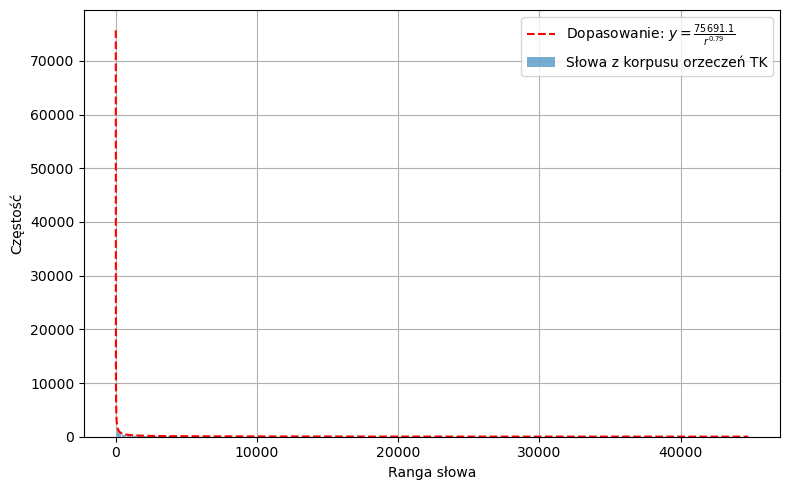

In [10]:
from scipy.optimize import curve_fit
dane['rank'] = np.arange(1, len(dane) + 1)

# 2. Model potęgowy: y = C * x^(-alpha)
def power_law(x, C, alpha):
    return C * x**(-alpha)

# 3. Dopasowanie modelu
xdata = dane['rank']
ydata = dane['number']
popt, _ = curve_fit(power_law, xdata, ydata)

# 4. Wartości dopasowane
C_fit, alpha_fit = popt

# 5. Wykres: dane + dopasowanie
plt.figure(figsize=(8, 5))
plt.bar(dane['rank'], dane['number'], label='Słowa z korpusu orzeczeń TK', alpha=0.6)
plt.plot(dane['rank'], power_law(dane['rank'], *popt), 'r--',
         label=fr'Dopasowanie: $y = \frac{{{C_fit:.1f}}}{{r^{{{alpha_fit:.2f}}}}}$')
plt.xlabel('Ranga słowa')
plt.ylabel('Częstość')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('wykres1.png')
plt.show()

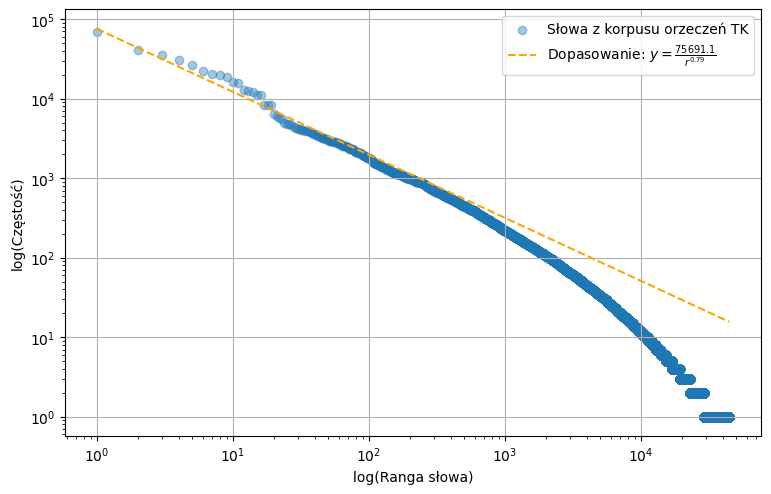

In [43]:
plt.figure(figsize=(8, 5))
plt.scatter(dane['rank'], dane['number'], label='Słowa z korpusu orzeczeń TK', alpha=0.4)
plt.plot(dane['rank'], power_law(dane['rank'], *popt), '--', color ='orange',
         label=fr'Dopasowanie: $y = \frac{{{C_fit:.1f}}}{{r^{{{alpha_fit:.2f}}}}}$')
plt.xlabel('log(Ranga słowa)')
plt.ylabel('log(Częstość)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xscale('log')
# plt.xlim(right=1e5+4792)
plt.yscale('log')
plt.savefig('wykres2.png')
plt.show()

In [12]:
print(len(token_counts))
print(token_counts)

44792
Counter({'w': 68992, 'z': 41314, 'art': 35760, 'i': 30404, 'do': 26728, 'o': 22327, 'nie': 20585, 'na': 19688, 'ust': 18822, 'ustawy': 16273, 'że': 15671, 'jest': 12959, 'r': 12504, 'się': 12037, 'przez': 11177, 'konstytucji': 11046, 'a': 8426, 'oraz': 8350, 'prawa': 8301, 'to': 6356, 'tym': 6089, 'lub': 5720, 'nr': 5498, 'od': 4907, 'poz': 4873, 'pkt': 4872, 'trybunał': 4692, 'ze': 4402, 'za': 4322, 'może': 4188, 'zakresie': 4113, 'tego': 4092, 'praw': 4040, 'przepisów': 3905, 'także': 3898, 'być': 3877, 'dla': 3835, 'co': 3715, 'konstytucyjny': 3592, 'prawo': 3548, 'które': 3498, 'państwa': 3391, 'są': 3355, 'sygn': 3318, 'ich': 3219, 'jak': 3195, 'postępowania': 3169, 'ma': 3110, 'zasady': 3084, 'jego': 2991, 'dnia': 2949, 'jako': 2912, 'należy': 2904, 'czy': 2898, 'u': 2890, 'sprawie': 2866, 'trybunału': 2862, 'związku': 2789, 'osób': 2772, 'wniosku': 2720, 'tej': 2704, 'tych': 2687, 'konstytucyjnego': 2604, 'po': 2576, 'przepisy': 2554, 'przepis': 2517, 'dz': 2515, 'sposób':

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
df['tokens_grounds'] = df['tokens_grounds'].apply(ast.literal_eval)
docs = df['tokens_grounds'].apply(lambda tokens: ' '.join(tokens)).tolist()
tfidf = TfidfVectorizer(
    smooth_idf=True, 
    use_idf=True,
    min_df = 5,
    max_df = 0.95,
    max_features=20,
    ngram_range=(1,2)
)
tfidf.fit(docs)
text = tfidf.transform(docs)

In [14]:
text = text.toarray()
print(text)

[[0.26128409 0.19882147 0.16458158 ... 0.24560705 0.20409775 0.28916549]
 [0.11680345 0.33630421 0.14944704 ... 0.         0.20528795 0.17312605]
 [0.2935631  0.1420565  0.11330513 ... 0.08058595 0.20795447 0.11944447]
 ...
 [0.1137401  0.15294588 0.37027723 ... 0.00874924 0.14522937 0.23342614]
 [0.29320795 0.21536062 0.12367652 ... 0.35603823 0.06134854 0.14486425]
 [0.18388498 0.16207575 0.18098165 ... 0.23642354 0.19664823 0.16439781]]


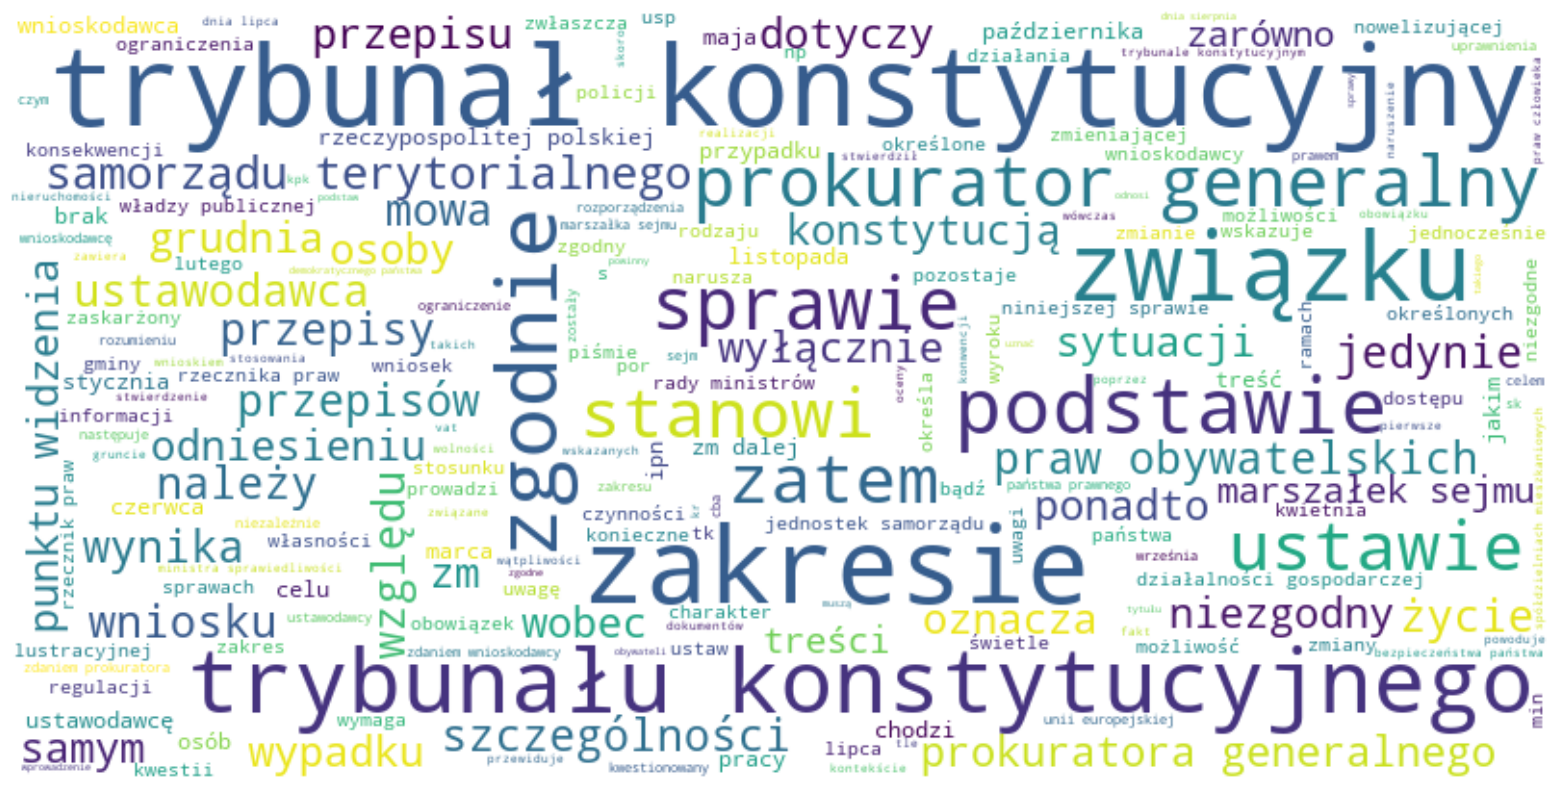

In [23]:
all_text = " ".join([" ".join(tokens) for tokens in df['tokens_grounds'].dropna()])

words = []
with open('polish.stopwords.txt', encoding='utf-8') as f:
    words = f.read().splitlines()
stopwords = set(STOPWORDS)
stopwords.update(words)
extra = ['ust', 'nr', 'poz', 'ust ustawy', 'ust konstytucji', 'ust', 'pkt ustawy', 'pkt', 'zaś', 'dz', 'sygn', 'otk', 'zu', 'tj', 'p']
for w in extra:
    stopwords.add(w)


wordcloud = WordCloud(width=800, height=400, background_color='white',colormap = "viridis", stopwords = stopwords).generate(all_text)

plt.figure(figsize=(20, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.savefig('chmura3.png')
plt.show()